# YOLO26 Orchid **Stage Detection** — Colab Training (v2)

This notebook fixes the issues from the previous `YOLO26_Colab_Training.ipynb`:

**Problems in the old notebook**
1. The validation set only had **3 images, all of one class (`Vegetative`)** → the "best" checkpoint could not be selected to detect all stages.
2. Heavy **class imbalance** in train (`Bud_formation=21`, `Flowering=161`, `Mature_Cane=77`, `Seedling=42`, `Vegetative=126`).
3. Tiny test set (12 images).
4. Result: `Bud_formation` recall = 0, `Seedling` recall = 0, `Vegetative` precision = 0.07 — model could not classify the **stage** correctly.

**What this notebook does differently**
1. **Re-splits** the dataset into train/valid/test with **stratified sampling** so every split contains every stage.
2. Uses **stronger augmentation** (mosaic + mixup + copy-paste + HSV + rotation) tuned for small datasets.
3. Trains **YOLO26m** at `imgsz=640` with **cosine LR**, **AdamW**, longer epochs, and a **higher classification loss weight** to push the model to discriminate stages.
4. Reports **per-class precision / recall / F1 / mAP** and the **confusion matrix**, so you can verify every stage is detected.
5. Provides a **`predict_stage()` helper** that takes any image and returns the dominant stage + confidence (the actual "detect correct stage" output).

**How to run** — open in Google Colab → `Runtime → Change runtime type → T4 GPU` → upload `YOLO26.zip` to `/content` (or to `MyDrive/`) → `Runtime → Run all`.

> Requires `ultralytics >= 8.4.0` for `yolo26*.pt` weights.

## 1. Install Ultralytics + verify GPU

In [1]:
%pip install -q "ultralytics>=8.4.0" "scikit-learn>=1.3" "matplotlib>=3.7" "pandas>=2.0"

import importlib.metadata as _md
import torch
from ultralytics import YOLO

print("ultralytics:", _md.version("ultralytics"))
print("torch       :", torch.__version__)

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU is not enabled. In Colab go to Runtime > Change runtime type > T4 GPU and run again."
    )

DEVICE = 0
print("CUDA        :", torch.cuda.is_available())
print("GPU         :", torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.2 MB/s eta 0:00:0000:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics: 8.4.48
torch       : 2.10.0+cu128
CUDA        : True
GPU         : Tesla T4


## 2. Locate and extract the dataset zip

Looks for `YOLO26.zip` in `/content` first, then `MyDrive/`. Falls back to any `.zip` in those locations.

In [3]:
from pathlib import Path
import shutil
import zipfile

try:
    from google.colab import drive
except Exception:
    drive = None

DATASET_ZIP_NAME = "YOLO26.zip"
EXTRACT_DIR = Path("/content/yolo26_dataset_raw")

zip_path = Path("/content") / DATASET_ZIP_NAME
if not zip_path.exists():
    zip_path = None

if zip_path is None and drive is not None:
    if not Path("/content/drive/MyDrive").exists():
        try:
            drive.mount("/content/drive", force_remount=False)
        except Exception as exc:
            print("Drive mount note:", exc)
    drive_zip = Path("/content/drive/MyDrive") / DATASET_ZIP_NAME
    if drive_zip.exists():
        zip_path = drive_zip

if zip_path is None:
    candidates = sorted(Path("/content").glob("*.zip"))
    zip_path = candidates[0] if candidates else None

if zip_path is None and drive is not None and Path("/content/drive/MyDrive").exists():
    candidates = sorted(Path("/content/drive/MyDrive").glob("*.zip"))
    zip_path = candidates[0] if candidates else None

if zip_path is None:
    raise FileNotFoundError(
        "Dataset zip not found. Upload YOLO26.zip to /content or /content/drive/MyDrive."
    )

print("Using dataset zip:", zip_path)

if EXTRACT_DIR.exists():
    shutil.rmtree(EXTRACT_DIR)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(EXTRACT_DIR)

print("Extracted to:", EXTRACT_DIR)

Mounted at /content/drive
Using dataset zip: /content/drive/MyDrive/YOLO26.zip
Extracted to: /content/yolo26_dataset_raw


## 3. Read the original `data.yaml` and gather all images + labels

Combines `train/`, `valid/`, `test/` into one pool so we can re-split it correctly.

In [4]:
import yaml
from collections import Counter

candidate_yamls = list(EXTRACT_DIR.rglob("data.yaml"))
if not candidate_yamls:
    raise FileNotFoundError("data.yaml not found inside the extracted dataset.")

def _yaml_score(p: Path):
    d = p.parent
    has_train = (d / "train" / "images").is_dir()
    has_val = (d / "valid" / "images").is_dir() or (d / "val" / "images").is_dir()
    return (0 if has_train and has_val else 1, len(p.parts))

ORIG_YAML = sorted(candidate_yamls, key=_yaml_score)[0]
ORIG_DIR = ORIG_YAML.parent
print("Original data.yaml:", ORIG_YAML)

with open(ORIG_YAML, "r") as f:
    orig_cfg = yaml.safe_load(f)

CLASS_NAMES = list(orig_cfg["names"]) if isinstance(orig_cfg.get("names"), (list, tuple)) else [
    orig_cfg["names"][i] for i in sorted(orig_cfg["names"].keys())
]
NUM_CLASSES = len(CLASS_NAMES)
print("Classes :", CLASS_NAMES)
print("nc      :", NUM_CLASSES)

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
all_images = []
for split in ("train", "valid", "val", "test"):
    split_imgs = ORIG_DIR / split / "images"
    if not split_imgs.is_dir():
        continue
    for p in split_imgs.iterdir():
        if p.suffix.lower() in IMG_EXTS:
            all_images.append(p)

print("Total images found:", len(all_images))
if len(all_images) < 30:
    raise RuntimeError("Not enough images; expected at least 30.")

def _label_path_for(img: Path) -> Path:
    return img.parent.parent / "labels" / (img.stem + ".txt")

usable = []
class_counts_total = Counter()
images_without_labels = 0
for img in all_images:
    lbl = _label_path_for(img)
    if not lbl.exists():
        images_without_labels += 1
        continue
    classes_in_img = []
    for line in lbl.read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        cid = int(line.split()[0])
        classes_in_img.append(cid)
    if not classes_in_img:
        continue
    usable.append((img, lbl, classes_in_img))
    class_counts_total.update(classes_in_img)

print(f"Images with labels      : {len(usable)}")
print(f"Images without labels   : {images_without_labels}")
print("\nObject counts per class (entire dataset):")
for cid in range(NUM_CLASSES):
    print(f"  {cid} {CLASS_NAMES[cid]:<16} : {class_counts_total[cid]}")

Original data.yaml: /content/yolo26_dataset_raw/data.yaml
Classes : ['Bud_formation', 'Flowering', 'Mature_Cane', 'Seedling', 'Vegetative']
nc      : 5
Total images found: 435
Images with labels      : 435
Images without labels   : 0

Object counts per class (entire dataset):
  0 Bud_formation    : 23
  1 Flowering        : 164
  2 Mature_Cane      : 79
  3 Seedling         : 46
  4 Vegetative       : 130


## 4. Stratified re-split into train / valid / test

We label each image with its **dominant class** (most-frequent class id in that image) and use `train_test_split` with `stratify=` so every split is guaranteed to contain every stage.

Default split: **80 / 10 / 10**.

In [5]:
from collections import Counter
import random
import shutil
import yaml
from pathlib import Path
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)

DATASET_DIR = Path("/content/yolo26_dataset")
if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)
for split in ("train", "valid", "test"):
    (DATASET_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (DATASET_DIR / split / "labels").mkdir(parents=True, exist_ok=True)

dominant_labels = []
for img, lbl, classes_in_img in usable:
    dominant = Counter(classes_in_img).most_common(1)[0][0]
    dominant_labels.append(dominant)

paths_train, paths_temp, y_train, y_temp = train_test_split(
    usable, dominant_labels,
    test_size=0.20, random_state=SEED, stratify=dominant_labels,
)
paths_valid, paths_test, y_valid, y_test = train_test_split(
    paths_temp, y_temp,
    test_size=0.50, random_state=SEED, stratify=y_temp,
)

def _copy_to_split(items, split_name):
    counts = Counter()
    for img, lbl, classes_in_img in items:
        dst_img = DATASET_DIR / split_name / "images" / img.name
        dst_lbl = DATASET_DIR / split_name / "labels" / lbl.name
        shutil.copy2(img, dst_img)
        shutil.copy2(lbl, dst_lbl)
        counts.update(classes_in_img)
    return counts

print("Re-splitting (stratified by dominant class)...")
counts_train = _copy_to_split(paths_train, "train")
counts_valid = _copy_to_split(paths_valid, "valid")
counts_test = _copy_to_split(paths_test, "test")

print(f"\n{'split':<8}{'images':>8}  per-class object counts")
for split, items, counts in [
    ("train", paths_train, counts_train),
    ("valid", paths_valid, counts_valid),
    ("test",  paths_test,  counts_test),
]:
    per_class = "  ".join(
        f"{CLASS_NAMES[c]}={counts[c]}" for c in range(NUM_CLASSES)
    )
    print(f"{split:<8}{len(items):>8}  {per_class}")

missing = []
for split, counts in [("train", counts_train), ("valid", counts_valid), ("test", counts_test)]:
    for cid in range(NUM_CLASSES):
        if counts[cid] == 0:
            missing.append((split, CLASS_NAMES[cid]))

if missing:
    print("\nWARNING: some splits are missing classes:", missing)
    print("Training will continue but consider collecting more images for the rare classes.")
else:
    print("\nEvery split contains every stage.")

DATA_YAML = DATASET_DIR / "data.yaml"
data_cfg = {
    "path": str(DATASET_DIR),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": NUM_CLASSES,
    "names": CLASS_NAMES,
}
with open(DATA_YAML, "w") as f:
    yaml.safe_dump(data_cfg, f, sort_keys=False)
print("\nWrote:", DATA_YAML)

Re-splitting (stratified by dominant class)...

split     images  per-class object counts
train        348  Bud_formation=18  Flowering=131  Mature_Cane=63  Seedling=37  Vegetative=106
valid         43  Bud_formation=3  Flowering=16  Mature_Cane=8  Seedling=4  Vegetative=12
test          44  Bud_formation=2  Flowering=17  Mature_Cane=8  Seedling=5  Vegetative=12

Every split contains every stage.

Wrote: /content/yolo26_dataset/data.yaml


## 5. Visualize class distribution per split

Quick sanity check: bar chart of object counts per stage in each split.

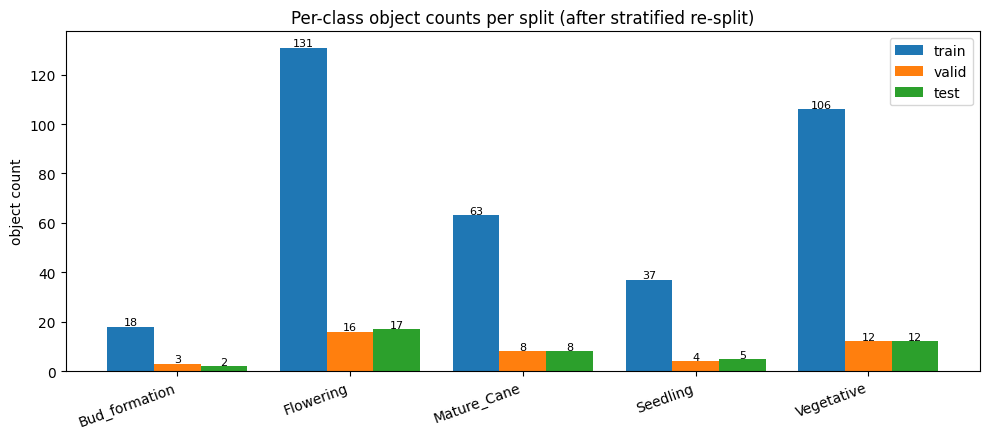

In [6]:
import numpy as np
import matplotlib.pyplot as plt

split_counts = {
    "train": [counts_train[c] for c in range(NUM_CLASSES)],
    "valid": [counts_valid[c] for c in range(NUM_CLASSES)],
    "test":  [counts_test[c]  for c in range(NUM_CLASSES)],
}
x = np.arange(NUM_CLASSES)
width = 0.27
fig, ax = plt.subplots(figsize=(10, 4.5))
for i, (split, vals) in enumerate(split_counts.items()):
    ax.bar(x + (i - 1) * width, vals, width, label=split)
    for xi, v in zip(x + (i - 1) * width, vals):
        ax.text(xi, v + 0.5, str(v), ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=20, ha="right")
ax.set_ylabel("object count")
ax.set_title("Per-class object counts per split (after stratified re-split)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Train YOLO26

Settings tuned for a small, imbalanced dataset:
- **`yolo26m.pt`** — more capacity than `s` so rare classes get learned.
- **`imgsz=640`** instead of 512 → finer features.
- **`AdamW`** + **cosine LR** + lower `lr0=0.002` → stable on small data.
- Strong augmentation: **mosaic + mixup + copy-paste + HSV + rotation**.
- Higher **`cls=1.0`** weight pushes the model to discriminate stages.
- `epochs=200` with `patience=50` so it actually has time to converge.

If you run out of GPU memory on a free T4, drop `batch` to `8` and `imgsz` to `512`, or switch to `yolo26s.pt`.

In [ ]:
from pathlib import Path
from ultralytics import YOLO

PRETRAINED   = "yolo26m.pt"
RUN_PROJECT  = "/content/yolo26_runs"
RUN_NAME     = "yolo26m_640_stage_v2"
IMG_SIZE     = 640
EPOCHS       = 200
BATCH        = 16

print("Pretrained :", PRETRAINED)
print("Data       :", DATA_YAML)
print("Run        :", f"{RUN_PROJECT}/{RUN_NAME}")

model = YOLO(PRETRAINED)

results = model.train(
    task="detect",
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    patience=100,
    device=DEVICE,
    project=RUN_PROJECT,
    name=RUN_NAME,
    exist_ok=True,

    optimizer="AdamW",
    lr0=0.002,
    lrf=0.01,
    cos_lr=True,
    weight_decay=0.0005,
    warmup_epochs=3.0,
    momentum=0.937,

    box=7.5,
    cls=1.0,
    dfl=1.5,

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=15.0,
    translate=0.1,
    scale=0.5,
    shear=2.0,
    perspective=0.0,
    flipud=0.0,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.15,
    copy_paste=0.30,
    erasing=0.4,
    close_mosaic=10,

    multi_scale=True,
    dropout=0.10,
    seed=SEED,
    verbose=True,
    plots=True,
    save=True,
)

BEST_MODEL_PATH = str(Path(RUN_PROJECT) / RUN_NAME / "weights" / "best.pt")
print("\nBest model:", BEST_MODEL_PATH)

Pretrained : yolo26m.pt
Data       : /content/yolo26_dataset/data.yaml
Run        : /content/yolo26_runs/yolo26m_640_stage_v2
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/yolo26_dataset/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=

## 7. Evaluate on validation and test splits

Reports overall **and per-class** Precision / Recall / F1 / mAP@0.5 / mAP@0.5-0.95.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
from ultralytics import YOLO

if not Path(BEST_MODEL_PATH).exists():
    raise FileNotFoundError(f"best.pt not found at {BEST_MODEL_PATH}")

best_model = YOLO(BEST_MODEL_PATH)

EVAL_DIR = Path(RUN_PROJECT) / RUN_NAME / "final_eval"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

def _safe_float(x):
    try:
        v = float(x)
        return v if not np.isnan(v) else None
    except Exception:
        return None

def _per_class_table(metrics, label):
    box = metrics.box
    p = np.atleast_1d(np.asarray(box.p, dtype=float))
    r = np.atleast_1d(np.asarray(box.r, dtype=float))
    map50 = np.atleast_1d(np.asarray(box.maps, dtype=float)) if hasattr(box, "maps") else np.full(NUM_CLASSES, np.nan)
    ap50 = None
    try:
        ap50 = np.atleast_1d(np.asarray(box.ap50, dtype=float))
    except Exception:
        ap50 = np.full(NUM_CLASSES, np.nan)

    f1 = np.where((p + r) > 0, 2 * p * r / (p + r + 1e-12), 0.0)
    rows = []
    class_idx_seen = list(metrics.ap_class_index) if hasattr(metrics, "ap_class_index") else list(range(len(p)))
    for i, cid in enumerate(class_idx_seen):
        rows.append({
            "class": CLASS_NAMES[int(cid)],
            "P": round(float(p[i]), 4),
            "R": round(float(r[i]), 4),
            "F1": round(float(f1[i]), 4),
            "mAP50": round(float(ap50[i]) if i < len(ap50) else float("nan"), 4),
            "mAP50-95": round(float(map50[i]) if i < len(map50) else float("nan"), 4),
        })
    df = pd.DataFrame(rows)
    overall = {
        "class": "ALL",
        "P": round(_safe_float(box.mp) or 0.0, 4),
        "R": round(_safe_float(box.mr) or 0.0, 4),
        "F1": round(2 * (_safe_float(box.mp) or 0.0) * (_safe_float(box.mr) or 0.0) /
                    max((_safe_float(box.mp) or 0.0) + (_safe_float(box.mr) or 0.0), 1e-12), 4),
        "mAP50": round(_safe_float(box.map50) or 0.0, 4),
        "mAP50-95": round(_safe_float(box.map) or 0.0, 4),
    }
    df = pd.concat([df, pd.DataFrame([overall])], ignore_index=True)
    print(f"\n=== {label} ===")
    print(df.to_string(index=False))
    return df

val_metrics = best_model.val(
    data=str(DATA_YAML), split="val", imgsz=IMG_SIZE, device=DEVICE,
    task="detect", plots=True, save_json=True, verbose=False,
    project=str(EVAL_DIR), name="val_eval", exist_ok=True,
)
test_metrics = best_model.val(
    data=str(DATA_YAML), split="test", imgsz=IMG_SIZE, device=DEVICE,
    task="detect", plots=True, save_json=True, verbose=False,
    project=str(EVAL_DIR), name="test_eval", exist_ok=True,
)

df_val  = _per_class_table(val_metrics,  "Validation metrics")
df_test = _per_class_table(test_metrics, "Test metrics")

df_val.to_csv(EVAL_DIR / "val_per_class.csv", index=False)
df_test.to_csv(EVAL_DIR / "test_per_class.csv", index=False)
print("\nSaved per-class tables to:", EVAL_DIR)

## 8. Show the confusion matrix and PR curves

Confirms that each stage is being predicted correctly, not just one or two dominant ones.

In [ ]:
from pathlib import Path
from IPython.display import Image as IPyImage, Markdown, display

for label, sub in [("Validation", "val_eval"), ("Test", "test_eval")]:
    eval_sub = EVAL_DIR / sub
    display(Markdown(f"### {label} plots — `{eval_sub}`"))
    for img_name in [
        "confusion_matrix.png",
        "confusion_matrix_normalized.png",
        "PR_curve.png",
        "F1_curve.png",
        "P_curve.png",
        "R_curve.png",
    ]:
        img_path = eval_sub / img_name
        if img_path.exists():
            display(Markdown(f"**{img_name}**"))
            display(IPyImage(filename=str(img_path)))

## 9. Predict on the test set with TTA

Uses **Test-Time Augmentation** (`augment=True`) and a slightly lower confidence threshold for better recall on rare stages.

In [ ]:
from pathlib import Path

PRED_PROJECT = "/content/yolo26_predictions"
PRED_NAME    = "test_predictions_tta"

test_images_dir = DATASET_DIR / "test" / "images"
if not test_images_dir.exists():
    raise FileNotFoundError(f"Test images dir missing: {test_images_dir}")

pred_results = best_model.predict(
    source=str(test_images_dir),
    imgsz=IMG_SIZE,
    conf=0.20,
    iou=0.50,
    augment=True,
    device=DEVICE,
    save=True,
    save_txt=True,
    save_conf=True,
    project=PRED_PROJECT,
    name=PRED_NAME,
    exist_ok=True,
    verbose=False,
)

PRED_DIR = Path(PRED_PROJECT) / PRED_NAME
print("Predictions saved at:", PRED_DIR)

## 10. `predict_stage()` helper — return the **dominant stage** for an image

`predict_stage(path)` runs the trained model on a single image and returns:

```python
{ "stage": "Flowering", "confidence": 0.87, "all_detections": [ ... ] }
```

The dominant stage is the one with the **highest summed confidence** across detections (more robust than just the top box, which avoids returning a single noisy false positive).

In [ ]:
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def predict_stage(image_path, conf=0.20, iou=0.50, augment=True, show=True):
    """Run the trained YOLO26 model on one image and return the dominant orchid stage.

    Parameters
    ----------
    image_path : str | Path
        Path to a single image.
    conf : float
        Min confidence for a detection to count.
    iou  : float
        NMS IoU threshold.
    augment : bool
        Enable test-time augmentation.
    show : bool
        If True, displays the image with the predicted boxes overlaid.

    Returns
    -------
    dict with keys: stage, confidence, all_detections.
    """
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(image_path)

    res = best_model.predict(
        source=str(image_path),
        imgsz=IMG_SIZE,
        conf=conf,
        iou=iou,
        augment=augment,
        device=DEVICE,
        save=False,
        verbose=False,
    )[0]

    score_per_class = defaultdict(float)
    detections = []
    if res.boxes is not None and len(res.boxes) > 0:
        cls_ids = res.boxes.cls.cpu().numpy().astype(int)
        confs = res.boxes.conf.cpu().numpy().astype(float)
        xyxy = res.boxes.xyxy.cpu().numpy()
        for cid, c, box in zip(cls_ids, confs, xyxy):
            name = CLASS_NAMES[int(cid)]
            score_per_class[name] += float(c)
            detections.append({
                "class": name, "conf": round(float(c), 4),
                "box": [round(float(v), 1) for v in box],
            })

    if score_per_class:
        stage = max(score_per_class, key=score_per_class.get)
        stage_conf = max(d["conf"] for d in detections if d["class"] == stage)
    else:
        stage, stage_conf = None, 0.0

    if show:
        plotted = res.plot()
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(plotted[..., ::-1])
        ax.set_title(f"{image_path.name}  ->  stage = {stage}  (conf={stage_conf:.2f})")
        ax.axis("off")
        plt.show()

    return {"stage": stage, "confidence": round(stage_conf, 4), "all_detections": detections}


sample_images = sorted((DATASET_DIR / "test" / "images").iterdir())[:6]
print("Predicting stage for first few test images:\n")
for img in sample_images:
    out = predict_stage(img, show=True)
    print(f"  {img.name}  ->  {out['stage']}  ({out['confidence']:.2f})")
    if out["all_detections"]:
        print("     all detections:", out["all_detections"])
    print()

## 11. Whole-test-set "stage classification" report

For each test image, compare the **predicted dominant stage** against the **ground-truth dominant stage** (from its label file). Reports overall stage accuracy + a per-stage breakdown.

In [ ]:
from collections import Counter
import pandas as pd
from pathlib import Path

test_imgs_dir = DATASET_DIR / "test" / "images"
test_lbls_dir = DATASET_DIR / "test" / "labels"

rows = []
for img in sorted(test_imgs_dir.iterdir()):
    if img.suffix.lower() not in IMG_EXTS:
        continue
    lbl = test_lbls_dir / (img.stem + ".txt")
    gt_classes = []
    if lbl.exists():
        for line in lbl.read_text().splitlines():
            line = line.strip()
            if line:
                gt_classes.append(int(line.split()[0]))
    gt_stage = CLASS_NAMES[Counter(gt_classes).most_common(1)[0][0]] if gt_classes else None

    pred = predict_stage(img, show=False)
    rows.append({
        "image":     img.name,
        "gt_stage":  gt_stage,
        "pred_stage":pred["stage"],
        "pred_conf": pred["confidence"],
        "correct":   gt_stage is not None and gt_stage == pred["stage"],
    })

df_stage = pd.DataFrame(rows)
print(df_stage.to_string(index=False))

evaluable = df_stage.dropna(subset=["gt_stage"])
if len(evaluable) > 0:
    overall = evaluable["correct"].mean()
    print(f"\nOverall stage accuracy on test set: {overall*100:.2f}%   ({int(evaluable['correct'].sum())}/{len(evaluable)})")
    per_stage = evaluable.groupby("gt_stage")["correct"].agg(["mean", "count"]).rename(columns={"mean": "accuracy"})
    per_stage["accuracy"] = (per_stage["accuracy"] * 100).round(2)
    print("\nPer-stage accuracy:")
    print(per_stage.to_string())

df_stage.to_csv(EVAL_DIR / "test_stage_classification.csv", index=False)
print("\nSaved:", EVAL_DIR / "test_stage_classification.csv")

## 12. Zip and download `best.pt` + run artifacts

Bundles the run dir, predictions and eval folders, then triggers a browser download. Also copies to `MyDrive/` if mounted, so it survives a Colab disconnect.

In [ ]:
from pathlib import Path
import shutil
import zipfile

try:
    from google.colab import files as colab_files
except Exception:
    colab_files = None

run_dir   = Path(RUN_PROJECT) / RUN_NAME
pred_dir  = Path(PRED_PROJECT) / PRED_NAME
eval_dir  = EVAL_DIR
data_yaml = DATA_YAML

EXPORT_ZIP = Path("/content/yolo26_stage_v2_output.zip")
if EXPORT_ZIP.exists():
    EXPORT_ZIP.unlink()

best_on_disk = run_dir / "weights" / "best.pt"
if best_on_disk.is_file():
    print("best.pt :", best_on_disk, "|", round(best_on_disk.stat().st_size / (1024 * 1024), 2), "MB")
else:
    print("WARNING: best.pt not found at", best_on_disk)

with zipfile.ZipFile(EXPORT_ZIP, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for prefix, folder in [
        ("runs", run_dir),
        ("predictions", pred_dir),
        ("metrics_eval", eval_dir),
    ]:
        if not Path(folder).exists():
            print("skip (missing):", folder)
            continue
        for fp in Path(folder).rglob("*"):
            if fp.is_file():
                zf.write(fp, arcname=(Path(prefix) / fp.relative_to(folder)).as_posix())
    if Path(data_yaml).exists():
        zf.write(data_yaml, arcname="data.yaml")

print("\nzip          :", EXPORT_ZIP)
print("zip size MB  :", round(EXPORT_ZIP.stat().st_size / (1024 * 1024), 2))

if colab_files is not None:
    try:
        colab_files.download(str(EXPORT_ZIP))
        print("Browser download started.")
    except Exception as exc:
        print("Browser download failed:", exc)
        print("Use the Files panel: right-click", EXPORT_ZIP, "-> Download")
else:
    print("Not running in Colab; zip is at:", EXPORT_ZIP)

drive_zip = Path("/content/drive/MyDrive/yolo26_stage_v2_output.zip")
if Path("/content/drive/MyDrive").exists():
    try:
        shutil.copy2(EXPORT_ZIP, drive_zip)
        print("Also copied to Drive:", drive_zip)
    except Exception as exc:
        print("Drive copy skipped:", exc)